# Logical Fallacy Detection in Presidential Debates
Dartmouth COSC 072, Winter 2025 <br>
Guidance from Professor Sarah Masud Preum <br>
Javier Agustin Rodillas

---

# Set Up

### Install Required Packages

Note: Run this cell *only* when you need to install or upgrade.

In [1]:
# Install required packages
%pip install -q pandas
%pip install -q matplotlib
%pip install -q seaborn
%pip install -q scikit-learn
%pip install -q langchain-dartmouth
%pip install -q python-dotenv
%pip install -q pyarrow
%pip install -q datasets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Load API keys
Load .env into the kernel and check for the presence of API Keys. This should be run before importing or calling the Dartmouth LLMs.

In [2]:
from pathlib import Path
from dotenv import load_dotenv
import os

env_path = Path('.') / '.env'
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print('.env file loaded successfully from ', env_path)
else:
    print('No .env file found at ', env_path, ' ensure that required API keys are set in the environment.')

DARTMOUTH_CHAT_API_KEY = os.getenv('DARTMOUTH_CHAT_API_KEY')
DARTMOUTH_API_KEY = os.getenv('DARTMOUTH_API_KEY')
if not DARTMOUTH_CHAT_API_KEY or not DARTMOUTH_API_KEY:
    print('Warning: One or more Dartmouth API keys are missing. Please set DARTMOUTH_CHAT_API_KEY and DARTMOUTH_API_KEY in your environment variables.')
else: 
    print('Dartmouth API keys found in environment.')

.env file loaded successfully from  .env
Dartmouth API keys found in environment.


### Imports + Version Check

Run after package install and after loading API keys from .env.

In [9]:
# Data libs and Visualization
import sys
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Random Forest Classifier Model and utilities
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Dartmouth LLM wrappers (requires API keys loaded above)
from langchain_dartmouth.llms import DartmouthLLM, ChatDartmouth, ChatDartmouthCloud
from pprint import pprint
import string

# Environment info and package versions
print('Python version:', sys.version)
print('Python executable:', sys.executable)
print('pandas version:', getattr(pd, '__version__', 'not-installed'))
import matplotlib
print('matplotlib version:', getattr(matplotlib, '__version__', 'not-installed'))
print('seaborn version:', getattr(sns, '__version__', 'not-installed'))
import sklearn
print('scikit-learn version:', getattr(sklearn, '__version__', 'not-installed'))

Python version: 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)]
Python executable: /Users/javierrodillas/Github/debate-fallacy-detector/.venv/bin/python
pandas version: 2.3.3
matplotlib version: 3.10.7
seaborn version: 0.13.2
scikit-learn version: 1.7.2


---
<br>

## Loading in the **Logical Fallacy** Dataset from Hugging Face:

You can find the source dataset from Hugging Face [here](https://huggingface.co/datasets/tasksource/logical-fallacy)

In [7]:
# Load the dataset from Hugging Face
dataset = load_dataset("tasksource/logical-fallacy")
data_frame = dataset['train'].to_pandas()

# Get Unique Fallacy Types
fallacy_labels = data_frame['logical_fallacies'].unique()
print(f"List of fallacy labels: \n{fallacy_labels}\n")

# Count occurences of each fallacy type
fallacy_counts = data_frame['logical_fallacies'].value_counts()
print(f"Fallacy distribution in our dataset: \n{fallacy_counts}")

List of fallacy labels: 
['appeal to emotion' 'false causality' 'ad populum' 'circular reasoning'
 'fallacy of relevance' 'faulty generalization' 'ad hominem'
 'fallacy of extension' 'equivocation' 'fallacy of logic'
 'fallacy of credibility' 'intentional' 'false dilemma']

Fallacy distribution in our dataset: 
logical_fallacies
faulty generalization     401
intentional               321
ad hominem                289
appeal to emotion         217
false causality           212
ad populum                209
fallacy of credibility    200
fallacy of logic          176
fallacy of relevance      175
false dilemma             143
circular reasoning        140
fallacy of extension      139
equivocation               58
Name: count, dtype: int64


## Clean Logical Fallacy Dataset

In [10]:
# PARAM:  String
# RETURN: Normalized version of String
def clean_text(text):
  text = text.lower()  # Convert to lowercase
  text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
  text = re.sub(r'[^\w\s.,!?]', '', text)  # Remove special characters except common punctuation
  return text.strip()

In [13]:
# Clean/normalize our dataset
data_frame['source_article'] = data_frame['source_article'].apply(clean_text)
data_frame.head()

# Filtering out less relevant fallacies (Got rid of 'intentional', 'equivocation', 'fallacy of logic')
relevant_fallacies = [
  'circular reasoning', 'faulty generalization', 'ad populum',
  'ad hominem', 'false causality', 'false dilemma', 'fallacy of extension',
  'fallacy of credibility', 'fallacy of relevance',  'appeal to emotion'
  ]
filtered_data = data_frame[data_frame['logical_fallacies'].isin(relevant_fallacies)]

# Check the remaining labels and counts
filtered_fallacy_counts = filtered_data['logical_fallacies'].value_counts()
print(f"NEW filtered Fallacy distribution in our dataset: \n{filtered_fallacy_counts}\n")

# Upsample the minority classes
max_count = filtered_data['logical_fallacies'].value_counts().max()
upsampled_data = filtered_data.groupby('logical_fallacies').apply(
  lambda x: x.sample(max_count, replace=True)
).reset_index(drop=True)

# Check the distribution after upsampling
upsampled_fallacy_counts = upsampled_data['logical_fallacies'].value_counts()
print(upsampled_fallacy_counts)

NEW filtered Fallacy distribution in our dataset: 
logical_fallacies
faulty generalization     401
ad hominem                289
appeal to emotion         217
false causality           212
ad populum                209
fallacy of credibility    200
fallacy of relevance      175
false dilemma             143
circular reasoning        140
fallacy of extension      139
Name: count, dtype: int64

logical_fallacies
ad hominem                401
ad populum                401
appeal to emotion         401
circular reasoning        401
fallacy of credibility    401
fallacy of extension      401
fallacy of relevance      401
false causality           401
false dilemma             401
faulty generalization     401
Name: count, dtype: int64


/var/folders/36/30x9pbms1cb1_m2vn1s44kbw0000gn/T/ipykernel_59428/3315430626.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  upsampled_data = filtered_data.groupby('logical_fallacies').apply(


---
<br>

# Random Forest Classifier

## Creating RF Classifier

In [15]:
# Split data into training and testing sets
train_data, test_data = train_test_split(upsampled_data, test_size=0.2, random_state=42)

# Split the training set into training and validation sets
train_data, validation_data = train_test_split(train_data, test_size=0.125, random_state=42)

# Check the size of our sets
print(f"Training set size: {len(train_data)} ~ 70%")
print(f"Validation set size: {len(validation_data)} ~ 10%")
print(f"Testing set size: {len(test_data)} ~ 20%")

# Initialize our vectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform training, validation and testing data
X_train = vectorizer.fit_transform(train_data['source_article'])
X_validation = vectorizer.transform(validation_data['source_article'])
X_test = vectorizer.transform(test_data['source_article'])

# Extract our labels
y_train = train_data['logical_fallacies']
y_validation = validation_data['logical_fallacies']
y_test = test_data['logical_fallacies']

Training set size: 2807 ~ 70%
Validation set size: 401 ~ 10%
Testing set size: 802 ~ 20%


## Training and Testing (**RF**)

In [16]:
# Initialize and use our random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)                 # Train model
y_validation_predictions = rf_classifier.predict(X_validation) # Make predictions

# Evaluate the model
print(f"Accuracy on validation set: {accuracy_score(y_validation, y_validation_predictions)}\n")
print(classification_report(y_validation, y_validation_predictions))

print("---\n")

# Evaluate on the test set
y_test_predictions = rf_classifier.predict(X_test)
print(f"Accuracy on test set: {accuracy_score(y_test, y_test_predictions)}\n")
print(classification_report(y_test, y_test_predictions))

Accuracy on validation set: 0.830423940149626

                        precision    recall  f1-score   support

            ad hominem       0.81      0.81      0.81        42
            ad populum       0.83      0.89      0.86        44
     appeal to emotion       0.87      0.79      0.83        33
    circular reasoning       0.82      0.91      0.86        55
fallacy of credibility       0.79      0.82      0.81        38
  fallacy of extension       0.92      0.83      0.87        29
  fallacy of relevance       0.87      0.90      0.89        30
       false causality       0.79      0.77      0.78        43
         false dilemma       0.85      0.91      0.88        45
 faulty generalization       0.80      0.67      0.73        42

              accuracy                           0.83       401
             macro avg       0.84      0.83      0.83       401
          weighted avg       0.83      0.83      0.83       401

---

Accuracy on test set: 0.8129675810473815

       

Using *RF Classifier* on **Debate Transcripts** in CSV format

In [ ]:
# Read and merge all CSV files
debate_data = pd.read_csv('all_debates_combined.csv')
debate_data['text'] = debate_data['text'].apply(clean_text)

# Standardize column names and clean text
debate_data.columns = debate_data.columns.str.strip().str.lower()
debate_data['text'] = debate_data['text'].astype(str).apply(clean_text)

# Transform text using the trained TF-IDF vectorizer
X_debate = vectorizer.transform(debate_data['text'])

fallacy_probs = rf_classifier.predict_proba(X_debate) # Probability estimates
fallacy_classes = rf_classifier.classes_  # Class labels
threshold = 0.5 # Confidence threshold

# Find the highest probability prediction for each statement
max_probs = fallacy_probs.max(axis=1)
predicted_labels = [
    fallacy_classes[i] if prob >= threshold else "None"
    for prob, i in zip(max_probs, fallacy_probs.argmax(axis=1))
]

# Store predictions and confidence scores
debate_data['predicted_fallacy'] = predicted_labels
debate_data['confidence'] = max_probs  # Save confidence scores for analysis

# Save results
debate_data.to_csv("debate_fallacy_predictions_filtered.csv", index=False)

## Data Visualization for RF Classifier

/var/folders/36/30x9pbms1cb1_m2vn1s44kbw0000gn/T/ipykernel_59428/3841761526.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fallacy_counts.index, y=fallacy_counts.values, palette="coolwarm")


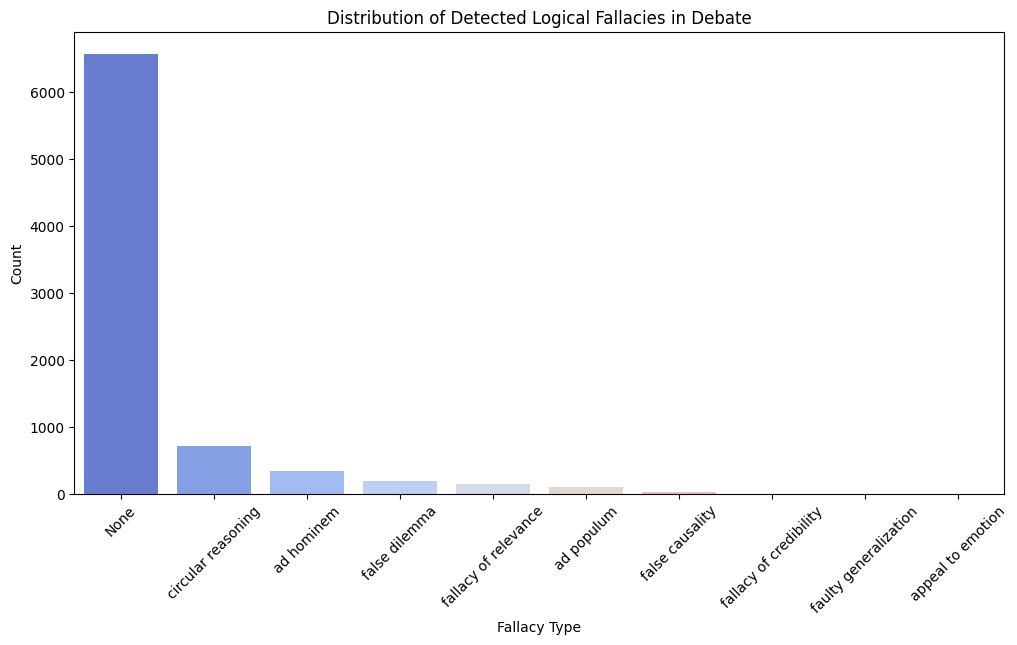

In [18]:
# Count fallacy occurrences
fallacy_counts = debate_data['predicted_fallacy'].value_counts()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=fallacy_counts.index, y=fallacy_counts.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Fallacy Type")
plt.ylabel("Count")
plt.title("Distribution of Detected Logical Fallacies in Debate")
plt.show()

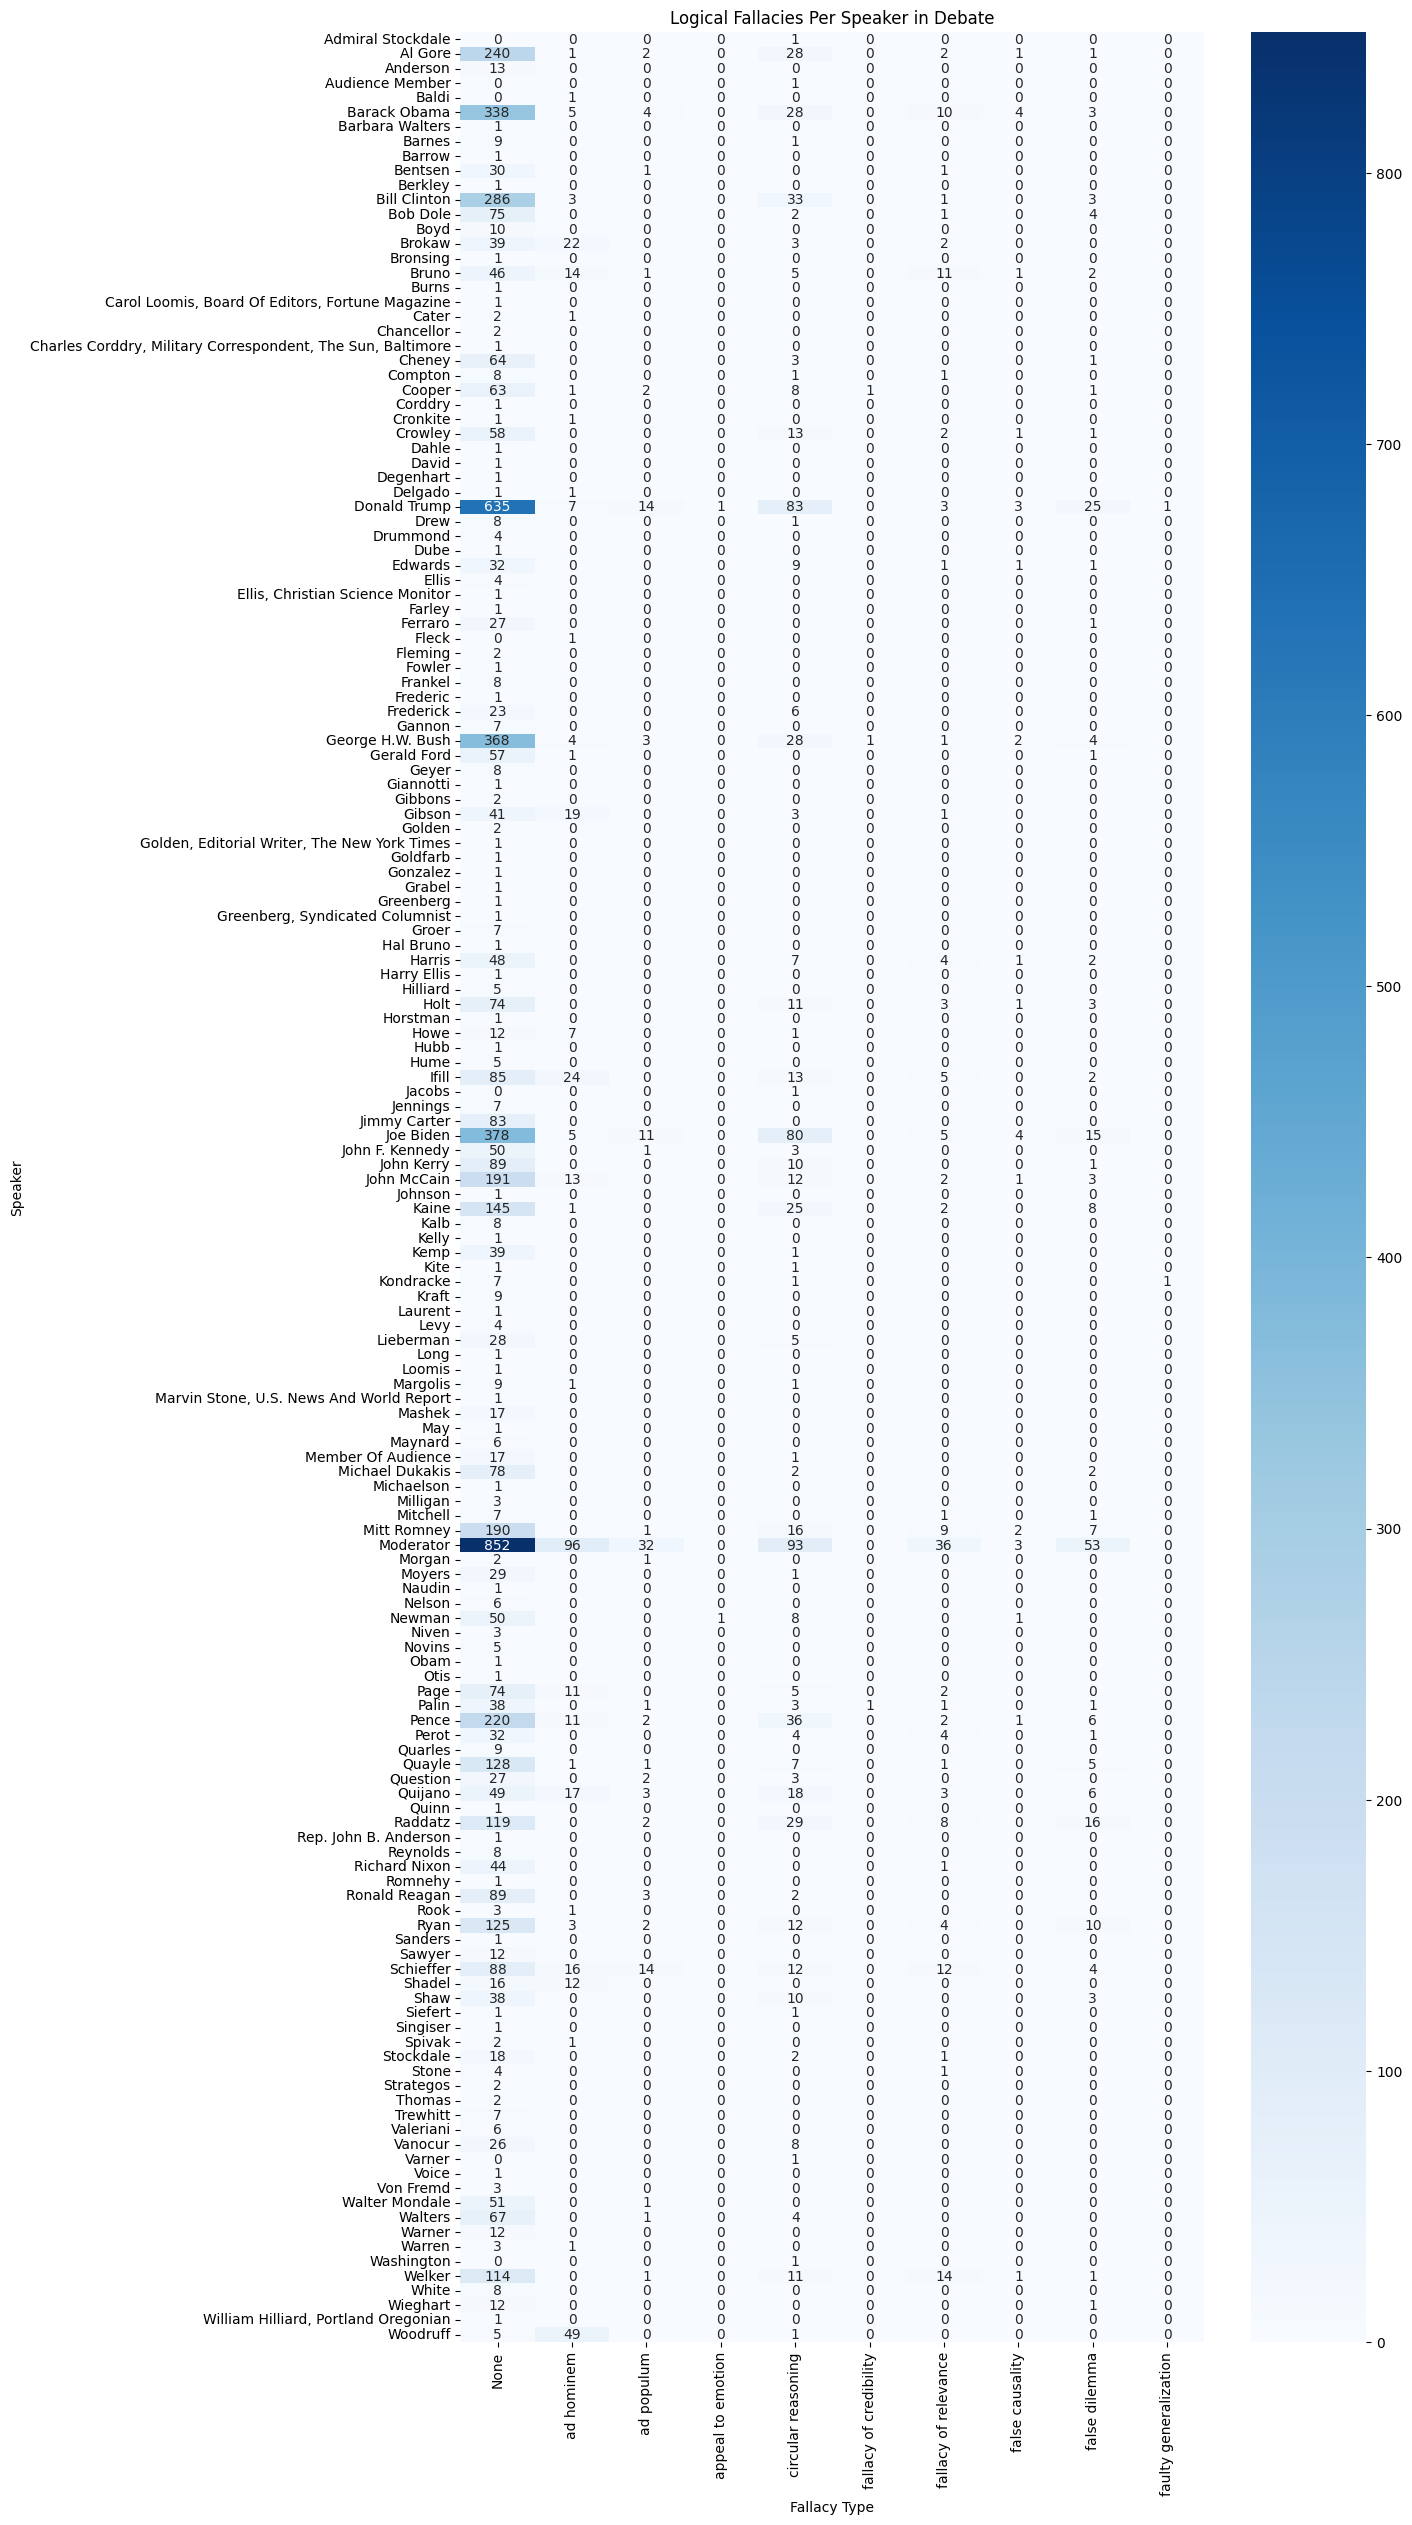

In [22]:
# Count fallacies per speaker
fallacy_speaker_counts = debate_data.groupby(['speaker', 'predicted_fallacy']).size().unstack(fill_value=0)

# Plot as heatmap
plt.figure(figsize=(12, 30))
sns.heatmap(fallacy_speaker_counts, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Fallacy Type")
plt.ylabel("Speaker")
plt.title("Logical Fallacies Per Speaker in Debate")
plt.show()

---
<br>

# Large Language Model

In [46]:
# print(ChatDartmouth.list())
# for entry in ChatDartmouth.list():
#     print(entry)

llm_models = [
  'meta.llama-3-2-3b-instruct', 
  ]

# "CodeLlama 13B Instruct HF"

### Helper Method Definitions

In [ ]:
def classify_fallacy(statement, model_name):
  '''
  params: 
    - Statement to classify
    - Name of LLM model to use
  return: 
    - Normalized fallacy label
      - "ad hominem", "ad populum", "appeal to emotion", "circular reasoning", 
        "fallacy of credibility", "fallacy of extension", "fallacy of relevance", 
        "false causality", "false dilemma", or "faulty generalization"
  '''

  # Use the provided model_name when initializing the ChatDartmouth wrapper
  llm = ChatDartmouth(model_name)  # Load model using model_name parameter

  prompt = f'''
  Instruction: Read the statement and classify it as one of the following:
  ["ad hominem", "ad populum", "appeal to emotion", "circular reasoning", "fallacy of credibility", "fallacy of extension", "fallacy of relevance", "false causality", "false dilemma", or "faulty generalization"].

  Return *ONLY* the fallacy label without explanation.

  Statement: "{statement}"

  Fallacy:
  '''

  try:
    response = llm.invoke(prompt).content
  except Exception as e:
    print(f'LLM error: {e}')
    return "None"
  
  return normalize_label(response)

# =================================================================================================================================

def classify_fallacy_debate(statement, model_name):
  '''
  params: 
    - Statement to classify
    - Name of LLM model to use
  return: 
    - Normalized fallacy label
      - "None", "ad hominem", "ad populum", "appeal to emotion", "circular reasoning", 
        "fallacy of credibility", "fallacy of extension", "fallacy of relevance", 
        "false causality", "false dilemma", or "faulty generalization"
  '''

  llm = ChatDartmouth(model_name)

  prompt = f'''
  Instruction: Read the sentence and respond with **only** the label, classify it as one of the following: "None", "ad hominem", "ad populum", "appeal to emotion", "circular reasoning", "fallacy of credibility", "fallacy of extension", "fallacy of relevance", "false causality", "false dilemma", or "faulty generalization".

  Statement: "{statement}"

  Label:
  '''

  try:
    response = llm.invoke(prompt).content
  except Exception as e:
    print(f'LLM error: {e}')
    return "None"
  
  return normalize_label(response)

# =================================================================================================================================

def normalize_label(label):
  '''
  params: 
    - fallacy label
  return: 
    - normalized fallacy label
  '''

  # Guard against non-string responses
  if not isinstance(label, str):
    return "None"
  
  # Remove punctuation and convert to lowercase
  label = label.lower().strip()
  label = label.translate(str.maketrans('', '', string.punctuation))

  if label not in relevant_fallacies:
    label = "None"

  return label

## Classification on the **Logical Fallacy** Dataset

In [47]:
# Split data into training and testing sets
train_data, test_data = train_test_split(upsampled_data, test_size=0.2, random_state=42)

# Split the training set into training and validation sets
train_data, validation_data = train_test_split(train_data, test_size=0.125, random_state=42)

# Check the size of our sets
print(f"Training set size: {len(train_data)} ~ 70%")
print(f"Validation set size: {len(validation_data)} ~ 10%")
print(f"Testing set size: {len(test_data)} ~ 20%")


# Apply classification for each model
for model in llm_models:
    print(f"Processing model: {model}")

    # Validation set predictions
    validation_data[f'predicted_{model}'] = validation_data['source_article'].apply(lambda x: classify_fallacy(x, model))
    validation_data[f'predicted_{model}'] = validation_data[f'predicted_{model}'].apply(normalize_label)

    # Validation set evaluation
    print(f"\nLLM Performance on Validation Set for {model}:")
    print(f"Accuracy: {accuracy_score(validation_data['logical_fallacies'], validation_data[f'predicted_{model}'])}")
    print(classification_report(validation_data['logical_fallacies'], validation_data[f'predicted_{model}'], zero_division=0))

    # Test set predictions
    test_data[f'predicted_{model}'] = test_data['source_article'].apply(lambda x: classify_fallacy(x, model))
    test_data[f'predicted_{model}'] = test_data[f'predicted_{model}'].apply(normalize_label)

    print("\n---\n")

    # Test set evaluation
    print(f"\nLLM Performance on Test Set for {model}:")
    print(f"Accuracy: {accuracy_score(test_data['logical_fallacies'], test_data[f'predicted_{model}'])}")
    print(classification_report(test_data['logical_fallacies'], test_data[f'predicted_{model}'], zero_division=0))

Training set size: 2807 ~ 70%
Validation set size: 401 ~ 10%
Testing set size: 802 ~ 20%
Processing model: meta.llama-3-2-3b-instruct

LLM Performance on Validation Set for meta.llama-3-2-3b-instruct:
Accuracy: 0.16458852867830423
                        precision    recall  f1-score   support

                  None       0.00      0.00      0.00         0
            ad hominem       0.47      0.19      0.27        42
            ad populum       1.00      0.02      0.04        44
     appeal to emotion       0.33      0.12      0.18        33
    circular reasoning       0.00      0.00      0.00        55
fallacy of credibility       0.50      0.03      0.05        38
  fallacy of extension       0.00      0.00      0.00        29
  fallacy of relevance       0.07      0.10      0.08        30
       false causality       0.69      0.26      0.37        43
         false dilemma       0.14      0.84      0.24        45
 faulty generalization       0.00      0.00      0.00        42


/Users/javierrodillas/Github/debate-fallacy-detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javierrodillas/Github/debate-fallacy-detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javierrodillas/Github/debate-fallacy-detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c


---


LLM Performance on Test Set for meta.llama-3-2-3b-instruct:
Accuracy: 0.1745635910224439
                        precision    recall  f1-score   support

                  None       0.00      0.00      0.00         0
            ad hominem       0.40      0.12      0.19        98
            ad populum       0.50      0.04      0.08        73
     appeal to emotion       0.40      0.18      0.25        92
    circular reasoning       0.00      0.00      0.00        76
fallacy of credibility       0.40      0.03      0.05        79
  fallacy of extension       0.14      0.01      0.02        81
  fallacy of relevance       0.16      0.24      0.19        79
       false causality       0.44      0.19      0.27        63
         false dilemma       0.14      0.86      0.24        86
 faulty generalization       0.00      0.00      0.00        75

              accuracy                           0.17       802
             macro avg       0.24      0.15      0.12       802
      

/Users/javierrodillas/Github/debate-fallacy-detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javierrodillas/Github/debate-fallacy-detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javierrodillas/Github/debate-fallacy-detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

## Classification on the **debate transcripts**

In [ ]:
# Load debate transcripts
# debate_folder = "csv_files"
debate_folder = "parsed_debates"
debate_files = [f for f in os.listdir(debate_folder) if f.endswith('.csv')]
debate_data = pd.concat([pd.read_csv(os.path.join(debate_folder, f)) for f in debate_files])

# Standardize column names & clean text
debate_data.columns = debate_data.columns.str.strip().str.lower()
debate_data['text'] = debate_data['text'].astype(str).apply(clean_text)

# Apply classification for each model
for model in llm_models:
  debate_data[f'predicted_fallacy_{model}'] = debate_data['text'].apply(lambda x: classify_fallacy_debate(x, model))

# Apply normalization to the 'predicted_fallacy' columns for each model
for model in llm_models:
  # Apply normalization to the predicted fallacy column for each model
  column_name = f'predicted_fallacy_{model}'
  debate_data[column_name] = debate_data[column_name].apply(normalize_label)

# Save results
debate_data.to_csv("debate_fallacy_comparison.csv", index=False)
print("Predictions saved for all models.")

Predictions saved for all models.


## Data Visualization for LLM Classifier

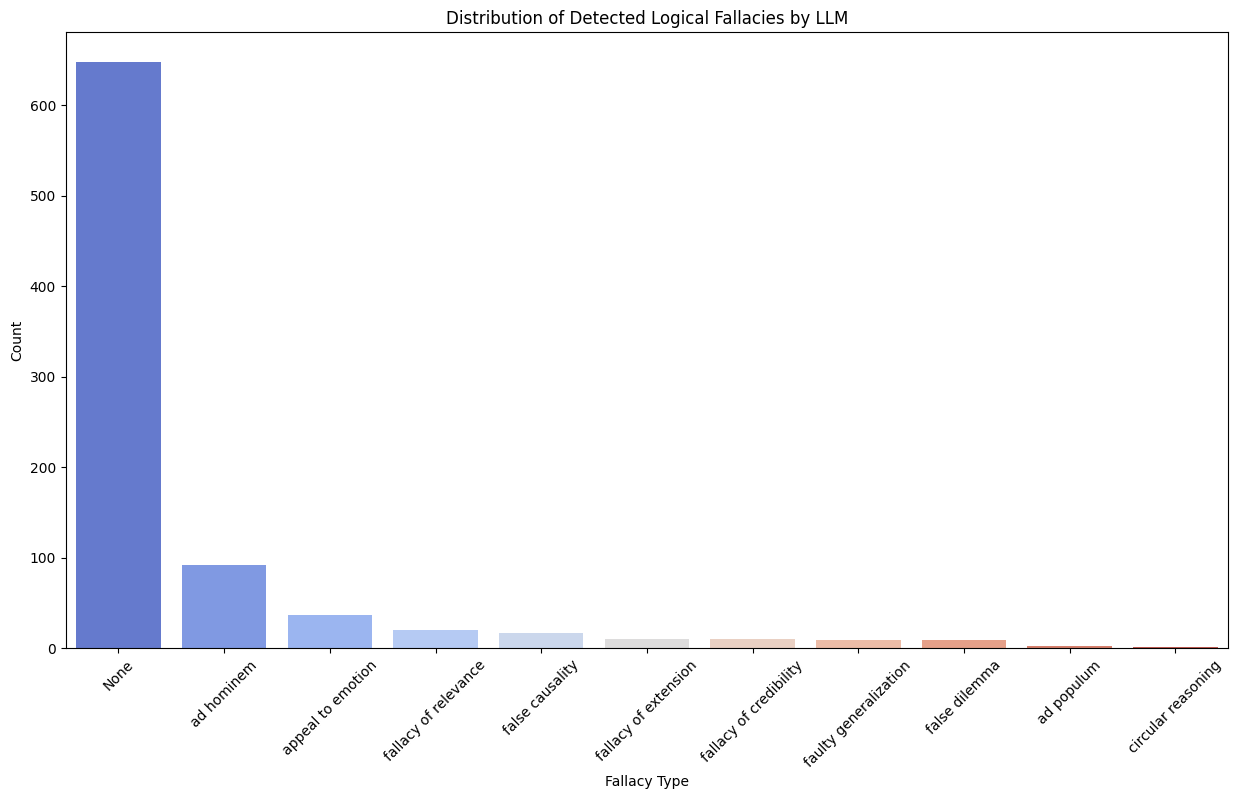

In [ ]:
# Count fallacy occurrences for the LLM model
fallacy_counts_llm = debate_data['predicted_fallacy_llama-3-8b-instruct'].value_counts()

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Fallacy Type': fallacy_counts_llm.index,
    'Count': fallacy_counts_llm.values,
    'data': 'LLM'  # Add a label for data source
})

# Plot
plt.figure(figsize=(15, 8))
sns.barplot(x='Fallacy Type', y='Count', data=plot_df, hue='Fallacy Type', palette="coolwarm", dodge=False, legend=False)
plt.xticks(rotation=45)
plt.xlabel("Fallacy Type")
plt.ylabel("Count")
plt.title("Distribution of Detected Logical Fallacies by LLM")
plt.show()

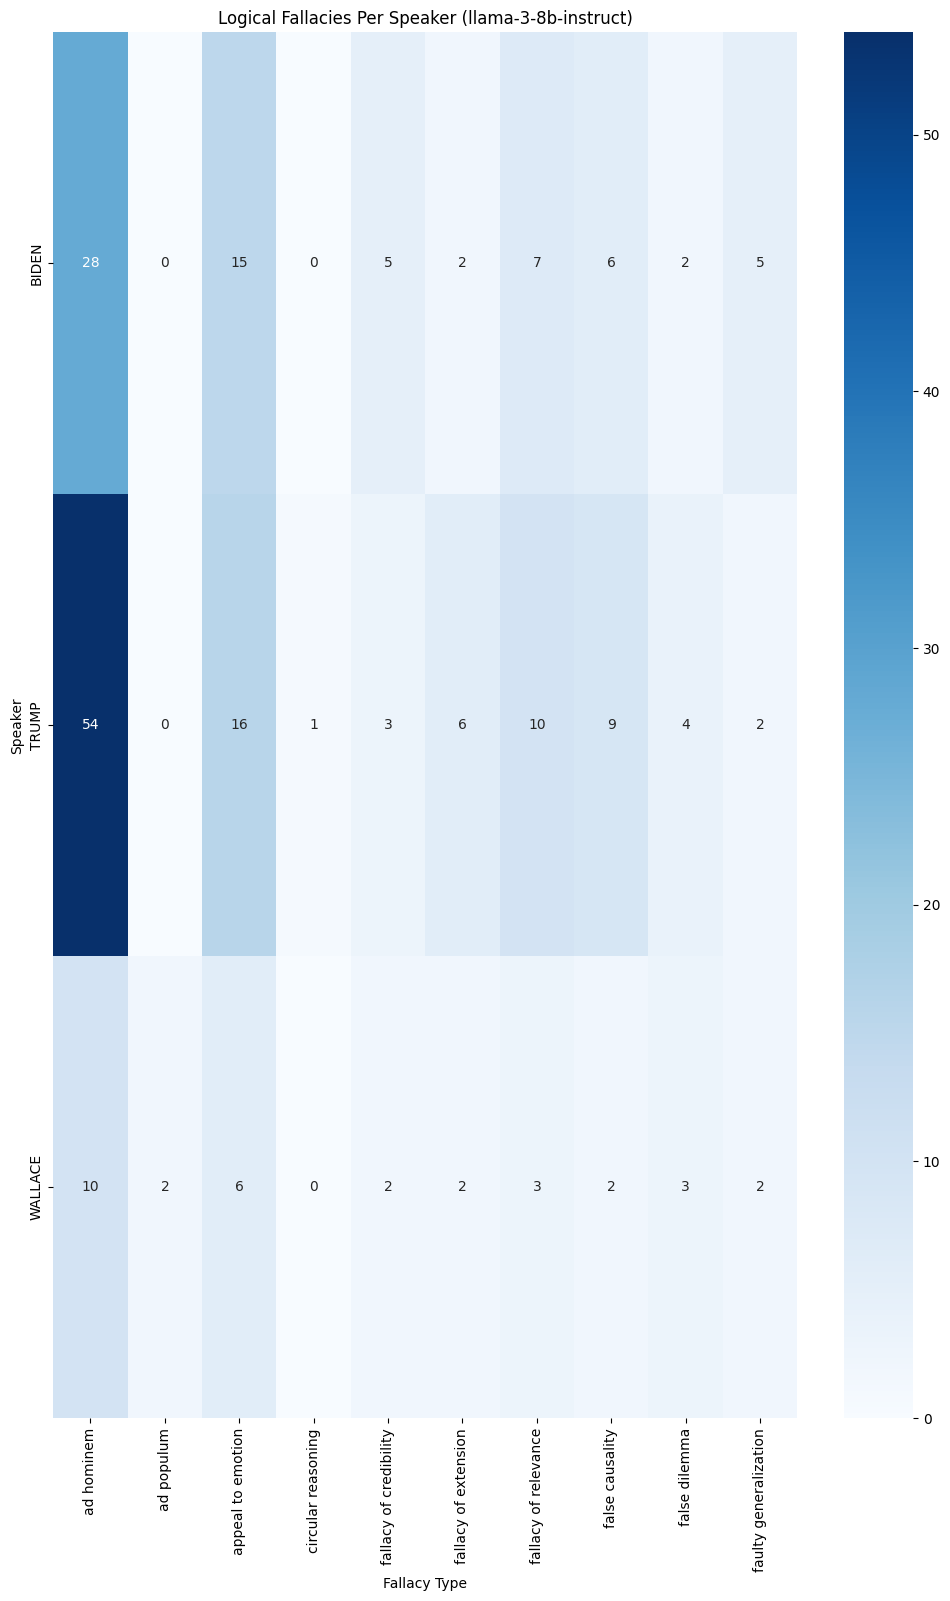

In [ ]:
# Count fallacies per speaker for the LLM model (e.g., "llama-3-8b-instruct")
fallacy_speaker_counts_llm = debate_data.groupby(['speaker', 'predicted_fallacy_llama-3-8b-instruct']).size().unstack(fill_value=0)
fallacy_speaker_counts_llm = fallacy_speaker_counts_llm.drop(columns=['None'], errors='ignore')

# Plot as heatmap
plt.figure(figsize=(12, 18))
sns.heatmap(fallacy_speaker_counts_llm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Fallacy Type")
plt.ylabel("Speaker")
plt.title(f"Logical Fallacies Per Speaker ({'llama-3-8b-instruct'})")
plt.show()